[*********************100%***********************]  10 of 10 completed


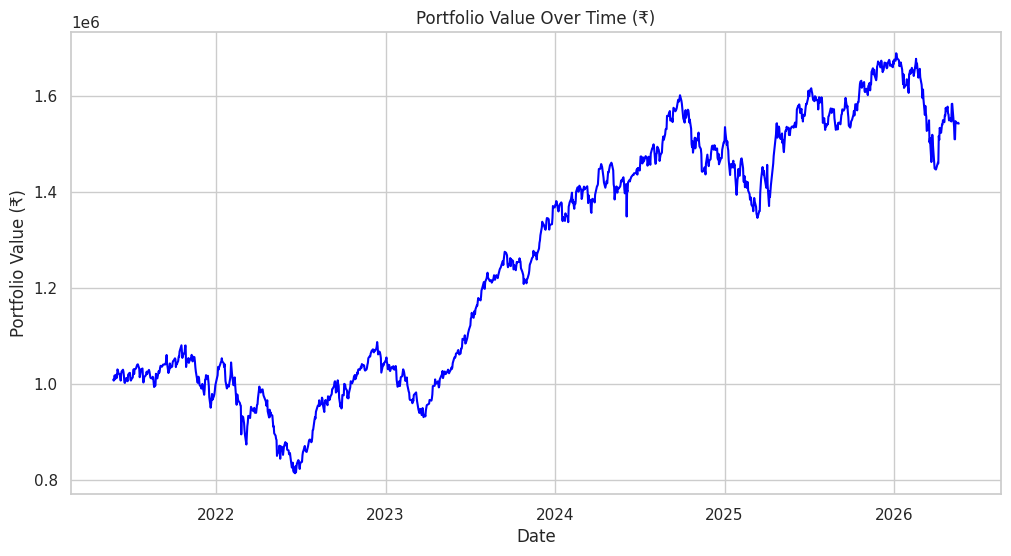

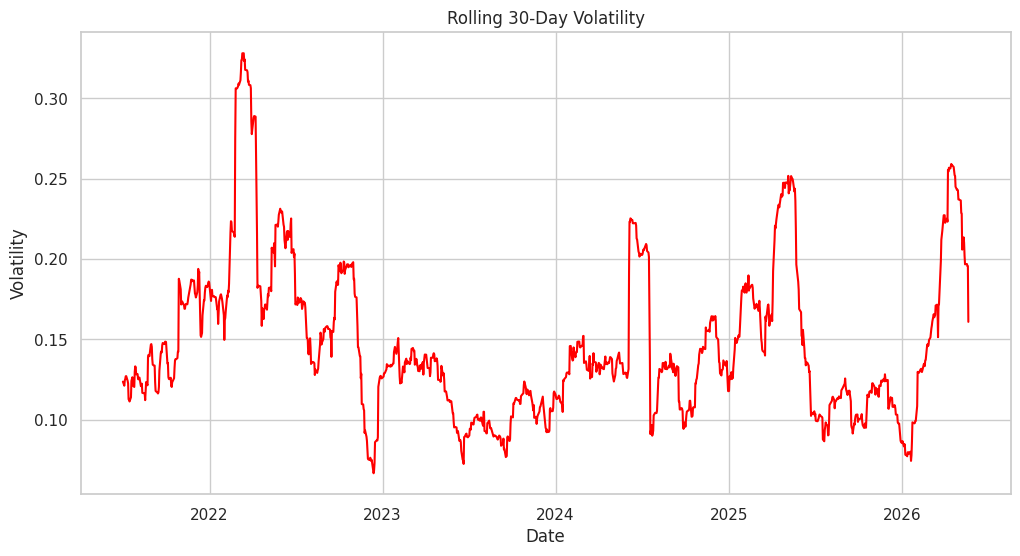

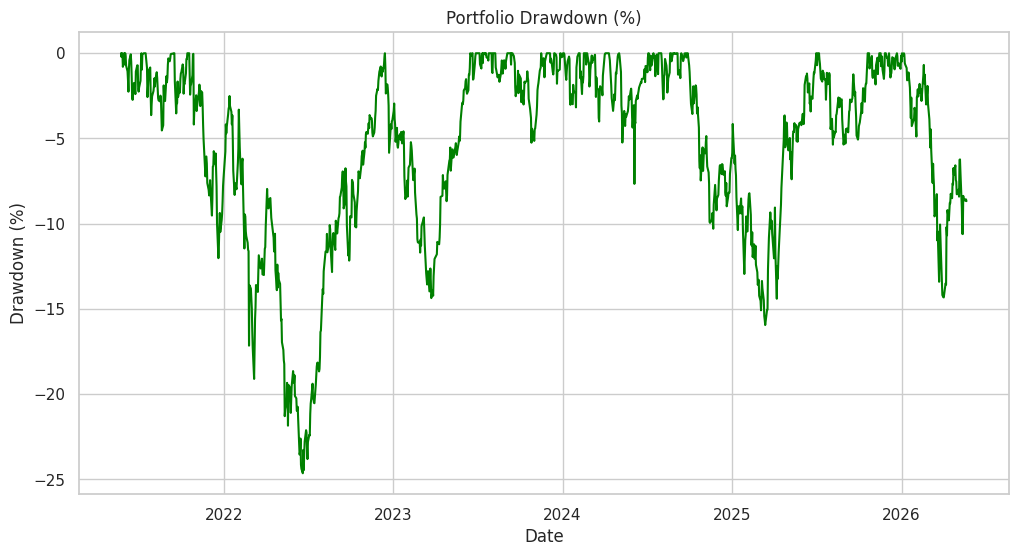

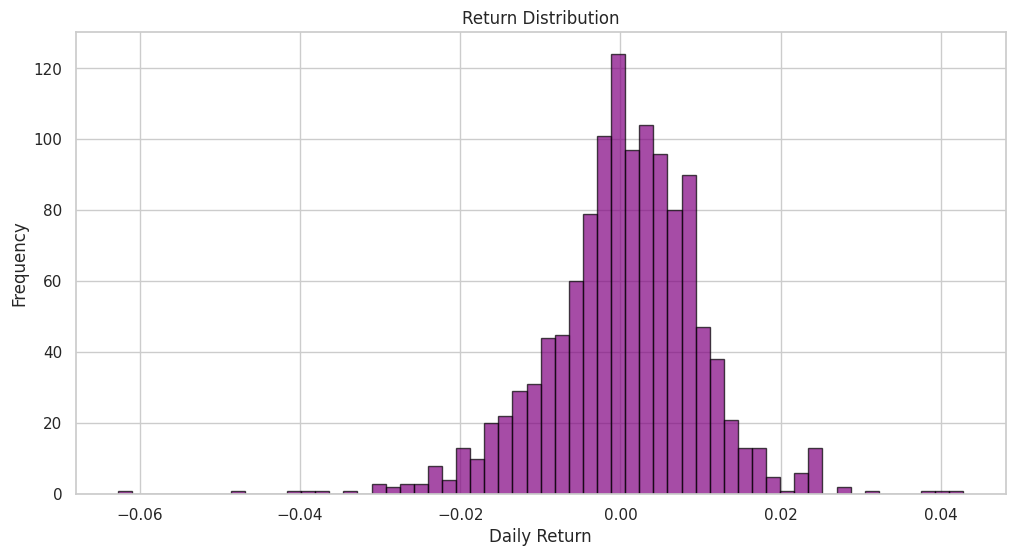

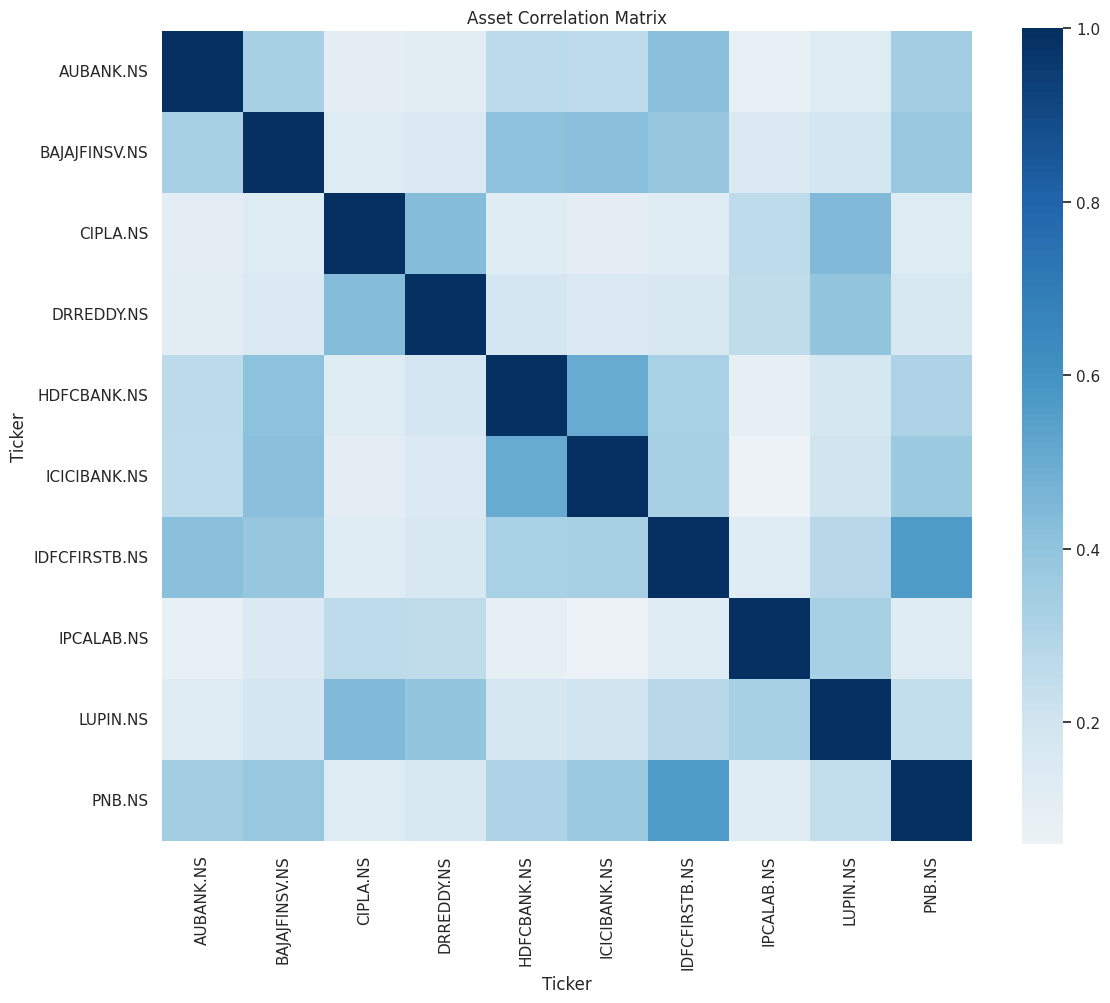

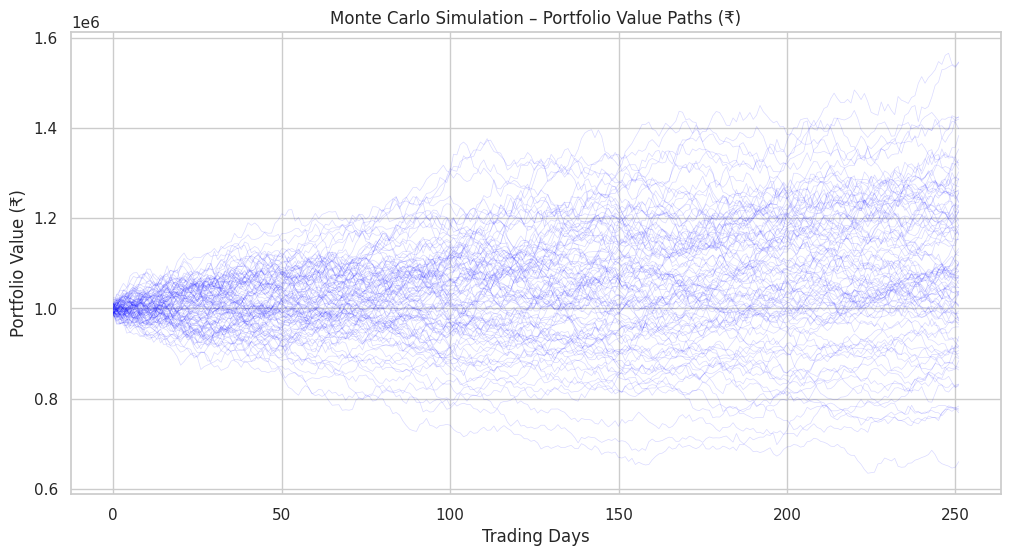

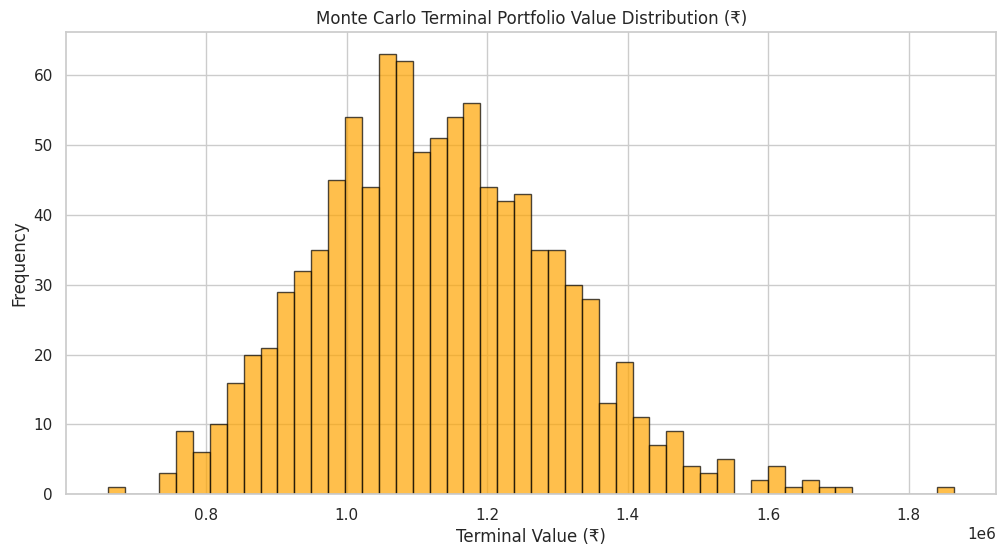

,Metric,Value
0,CAGR (%),9.2226
1,Annual Volatility (%),15.4315
2,Sharpe Ratio,0.2376
3,Max Drawdown (%),-24.6335
4,Max Drawdown (₹),-246334.5100


,Risk Measure,Loss Amount
0,Historical VaR (₹),-15670.28
1,Parametric VaR (₹),-15592.03
2,Monte Carlo VaR (₹),-15587.90
3,Historical ES (₹),-22925.17
4,Monte Carlo ES (₹),-19626.55


(                  Metric        Value
 0               CAGR (%)       9.2226
 1  Annual Volatility (%)      15.4315
 2           Sharpe Ratio       0.2376
 3       Max Drawdown (%)     -24.6335
 4       Max Drawdown (₹) -246334.5100,
           Risk Measure  Loss Amount
 0   Historical VaR (₹)    -15670.28
 1   Parametric VaR (₹)    -15592.03
 2  Monte Carlo VaR (₹)    -15587.90
 3    Historical ES (₹)    -22925.17
 4   Monte Carlo ES (₹)    -19626.55)

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_squared_error
import time
from datetime import timedelta

# ---------------------------------------------------------
# SAFE DOWNLOAD FUNCTION
# ---------------------------------------------------------
def safe_download(symbols, period="5y"):
    df = yf.download(symbols, period=period, auto_adjust=False)

    if isinstance(symbols, list):
        try:
            return df["Adj Close"].ffill().bfill()
        except:
            return df["Close"].ffill().bfill()

    if "Adj Close" in df.columns:
        return df["Adj Close"].ffill().bfill()
    elif "Close" in df.columns:
        return df["Close"].ffill().bfill()

    raise ValueError("No valid price data found")

# ---------------------------------------------------------
# MONTE CARLO SIMULATION
# ---------------------------------------------------------
def monte_carlo_simulation(portfolio_returns, n_simulations=1000, n_days=252):
    mu = portfolio_returns.mean()
    sigma = portfolio_returns.std()

    simulated_log_returns = np.random.normal(
        mu, sigma, size=(n_days, n_simulations)
    )

    simulated_paths = np.exp(simulated_log_returns.cumsum(axis=0))
    return simulated_paths, simulated_log_returns

# ---------------------------------------------------------
# PORTFOLIO ANALYSIS WITH INVESTMENT AMOUNT (Matplotlib plots)
# ---------------------------------------------------------
def portfolio_analysis(
    portfolio_list,
    period="5y",
    risk_free_rate=0.065,
    var_level=0.95,
    invest_amount=1_000_000  # ₹10 lakh default
):

    TRADING_DAYS = 252

    prices = safe_download(portfolio_list, period)
    prices = prices.dropna(axis=1, how='all')
    log_returns = np.log(prices / prices.shift(1)).dropna()

    portfolio_returns = log_returns.mean(axis=1)
    cumulative_returns = (1 + portfolio_returns).cumprod()

    portfolio_value = invest_amount * cumulative_returns

    # -----------------------------
    # METRICS
    # -----------------------------
    n_days = len(portfolio_returns)

    cagr = (cumulative_returns.iloc[-1] ** (TRADING_DAYS / n_days) - 1) * 100
    vol = portfolio_returns.std() * np.sqrt(TRADING_DAYS) * 100
    sharpe = ((portfolio_returns.mean() * TRADING_DAYS) - risk_free_rate) / (vol / 100)

    drawdown = cumulative_returns / cumulative_returns.cummax() - 1
    max_dd_pct = drawdown.min() * 100
    max_dd_amt = invest_amount * drawdown.min()

    # -----------------------------
    # VISUALIZATIONS (Matplotlib)
    # -----------------------------
    # 1. Portfolio value over time
    plt.figure()
    plt.plot(portfolio_value.index, portfolio_value.values, color='blue')
    plt.title("Portfolio Value Over Time (₹)")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value (₹)")
    plt.grid(True)
    plt.show()

    # 2. Rolling 30-day volatility
    rolling_vol = portfolio_returns.rolling(30).std() * np.sqrt(TRADING_DAYS)
    plt.figure()
    plt.plot(rolling_vol.index, rolling_vol.values, color='red')
    plt.title("Rolling 30-Day Volatility")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.grid(True)
    plt.show()

    # 3. Drawdown (%)
    plt.figure()
    plt.plot(drawdown.index, drawdown.values * 100, color='green')
    plt.title("Portfolio Drawdown (%)")
    plt.xlabel("Date")
    plt.ylabel("Drawdown (%)")
    plt.grid(True)
    plt.show()

    # 4. Return distribution (histogram)
    plt.figure()
    plt.hist(portfolio_returns, bins=60, color='purple', edgecolor='black', alpha=0.7)
    plt.title("Return Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # 5. Asset correlation matrix (heatmap)
    corr_matrix = log_returns.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='RdBu', center=0, square=True)
    plt.title("Asset Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # MONTE CARLO
    # -----------------------------
    paths, sim_log_returns = monte_carlo_simulation(portfolio_returns)
    mc_terminal_values = invest_amount * paths[-1]

    # 6. Monte Carlo paths (first 100)
    plt.figure()
    for i in range(min(100, paths.shape[1])):
        plt.plot(invest_amount * paths[:, i], linewidth=0.5, alpha=0.15, color='blue')
    plt.title("Monte Carlo Simulation – Portfolio Value Paths (₹)")
    plt.xlabel("Trading Days")
    plt.ylabel("Portfolio Value (₹)")
    plt.grid(True)
    plt.show()

    # 7. Monte Carlo terminal distribution
    plt.figure()
    plt.hist(mc_terminal_values, bins=50, color='orange', edgecolor='black', alpha=0.7)
    plt.title("Monte Carlo Terminal Portfolio Value Distribution (₹)")
    plt.xlabel("Terminal Value (₹)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # -----------------------------
    # VALUE AT RISK (VaR)
    # -----------------------------
    alpha = 1 - var_level

    # % VaR
    hist_var_pct = np.percentile(portfolio_returns, alpha * 100)
    para_var_pct = portfolio_returns.mean() + portfolio_returns.std() * norm.ppf(alpha)
    mc_var_pct = np.percentile(sim_log_returns.flatten(), alpha * 100)

    # ₹ VaR
    hist_var_amt = invest_amount * hist_var_pct
    para_var_amt = invest_amount * para_var_pct
    mc_var_amt = invest_amount * mc_var_pct

    # Expected Shortfall
    hist_es_pct = portfolio_returns[portfolio_returns <= hist_var_pct].mean()
    mc_es_pct = sim_log_returns.flatten()[sim_log_returns.flatten() <= mc_var_pct].mean()

    hist_es_amt = invest_amount * hist_es_pct
    mc_es_amt = invest_amount * mc_es_pct

    # -----------------------------
    # SUMMARY TABLES
    # -----------------------------
    performance_summary = pd.DataFrame({
        "Metric": [
            "CAGR (%)",
            "Annual Volatility (%)",
            "Sharpe Ratio",
            "Max Drawdown (%)",
            "Max Drawdown (₹)"
        ],
        "Value": [
            round(cagr, 4),
            round(vol, 4),
            round(sharpe, 4),
            round(max_dd_pct, 4),
            round(max_dd_amt, 2)
        ]
    })

    var_summary = pd.DataFrame({
        "Risk Measure": [
            "Historical VaR (₹)",
            "Parametric VaR (₹)",
            "Monte Carlo VaR (₹)",
            "Historical ES (₹)",
            "Monte Carlo ES (₹)"
        ],
        "Loss Amount": [
            round(hist_var_amt, 2),
            round(para_var_amt, 2),
            round(mc_var_amt, 2),
            round(hist_es_amt, 2),
            round(mc_es_amt, 2)
        ]
    })

    display(performance_summary)
    display(var_summary)

    return performance_summary, var_summary

# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------
portfolio_list = [
    "IDFCFIRSTB.NS", "PNB.NS", "AUBANK.NS", "HDFCBANK.NS", "ICICIBANK.NS",
    "BAJAJFINSV.NS", "CIPLA.NS", "DRREDDY.NS", "IPCALAB.NS", "LUPIN.NS"
]

portfolio_analysis(
    portfolio_list=portfolio_list,
    period="5y",
    risk_free_rate=0.0635,
    var_level=0.95,
    invest_amount=1_000_000  # ₹10 lakh
)

In [2]:
# import numpy as np
# import cvxpy as cp

# def markowitz_optimiser(returns, target_return):
#     mu = returns.mean().values
#     Sigma = returns.cov().values
#     n = len(mu)

#     w = cp.Variable(n)
#     constraints = [cp.sum(w) == 1, w >= 0, mu @ w >= target_return]
#     prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma)), constraints)
#     prob.solve()
#     return w.value

[*********************100%***********************]  10 of 10 completed



EQUAL‑WEIGHTED PORTFOLIO ANALYSIS


[*********************100%***********************]  10 of 10 completed


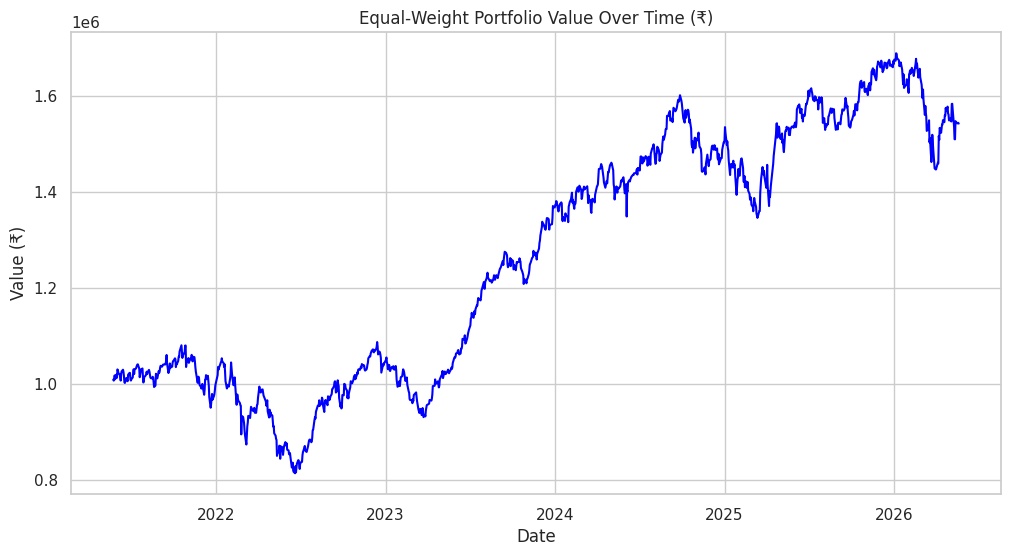

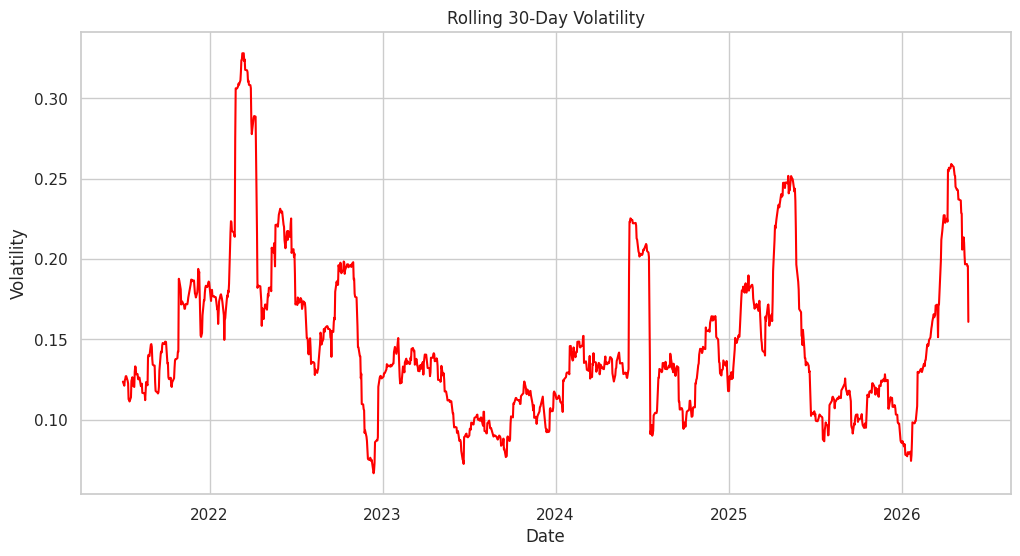

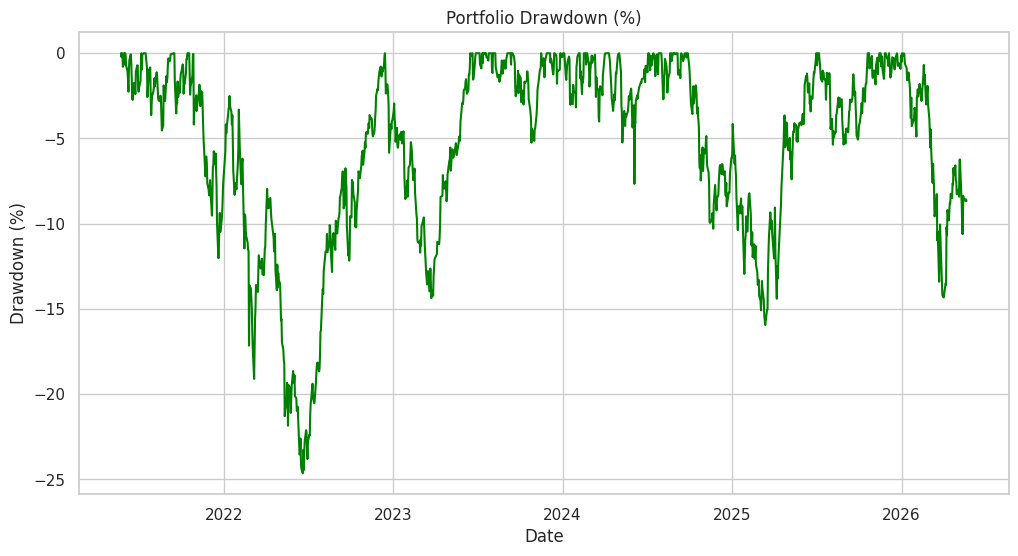

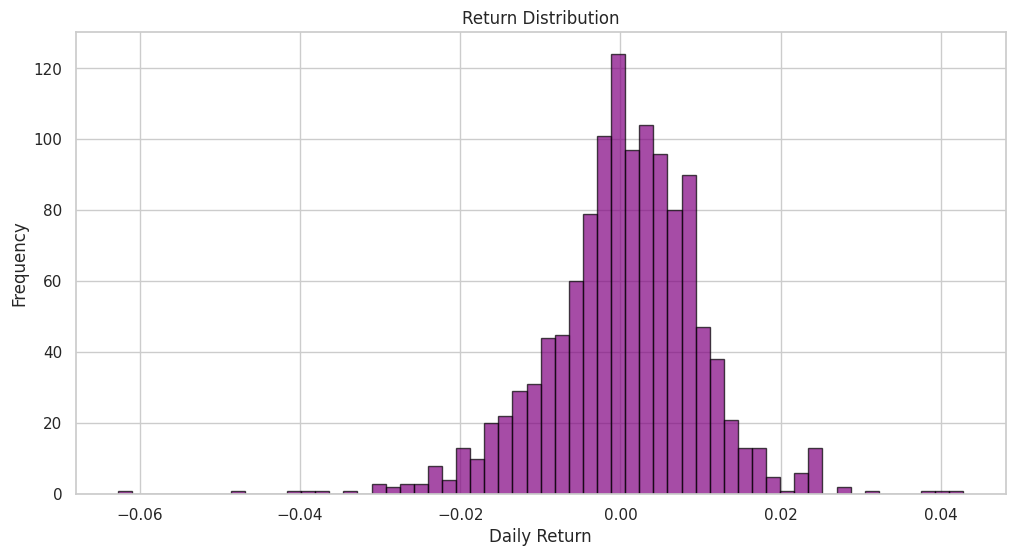

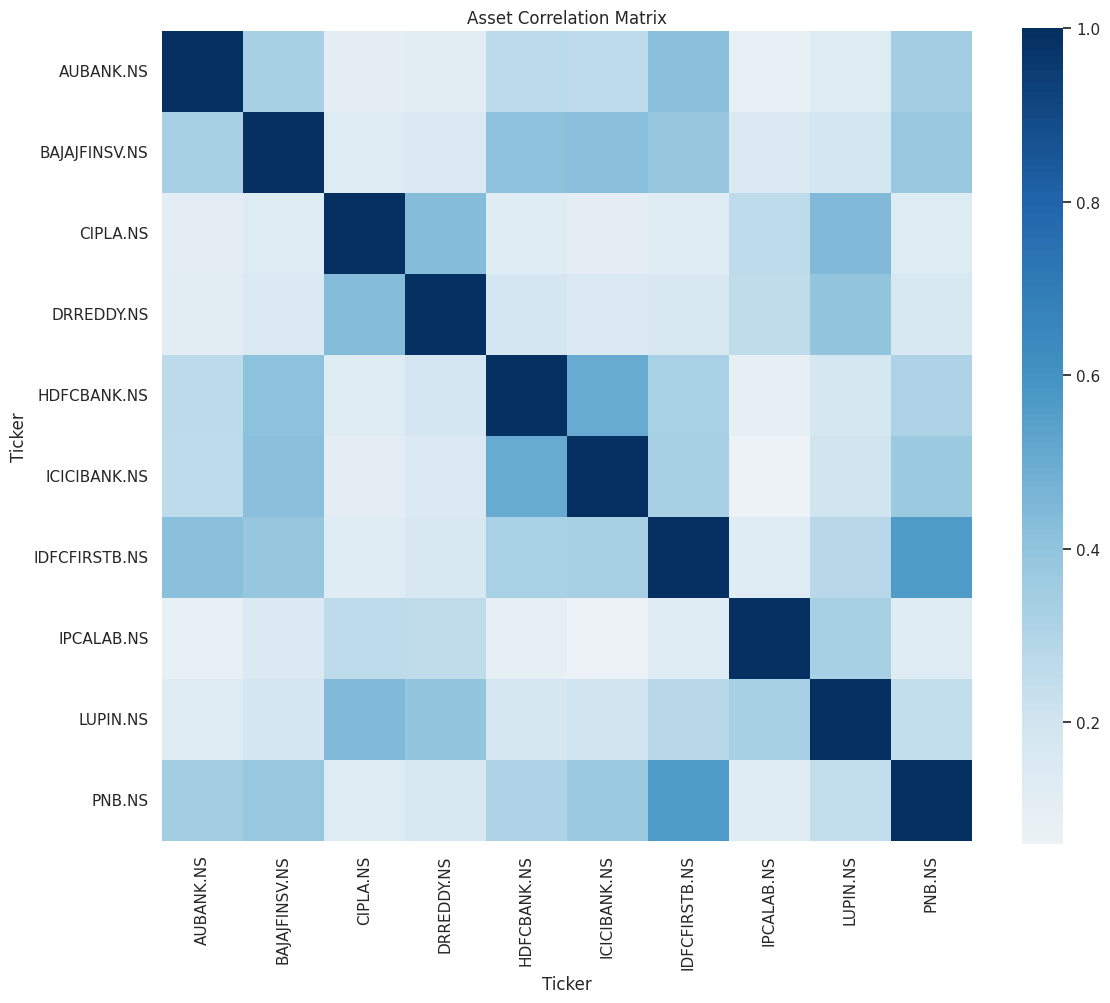

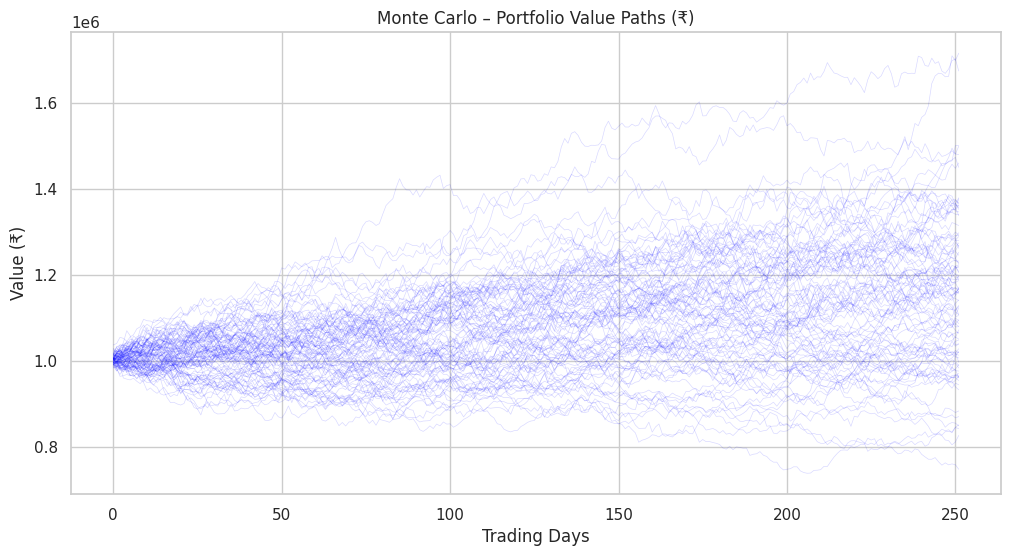

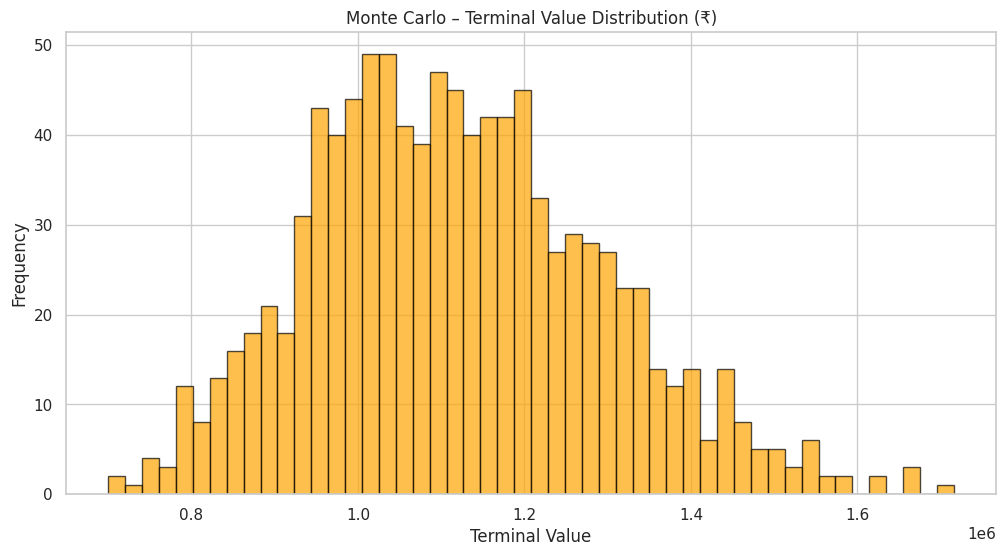

,Metric,Value
0,CAGR (%),9.2236
1,Annual Volatility (%),15.4315
2,Sharpe Ratio,0.2377
3,Max Drawdown (%),-24.6334
4,Max Drawdown (₹),-246334.4600


,Risk Measure,Loss Amount
0,Historical VaR (₹),-15670.28
1,Parametric VaR (₹),-15591.98
2,Monte Carlo VaR (₹),-15619.14
3,Historical ES (₹),-22925.17
4,Monte Carlo ES (₹),-19713.55



MARKOWITZ MEAN‑VARIANCE OPTIMISATION
Minimum Variance Portfolio: Return = 0.03%, Vol = 0.85%
Tangency Portfolio: Return = 0.09%, Vol = 2.23%, Sharpe = -2.8148
Equal‑Weight Portfolio: Return = 0.04%, Vol = 0.97%, Sharpe = -6.4914


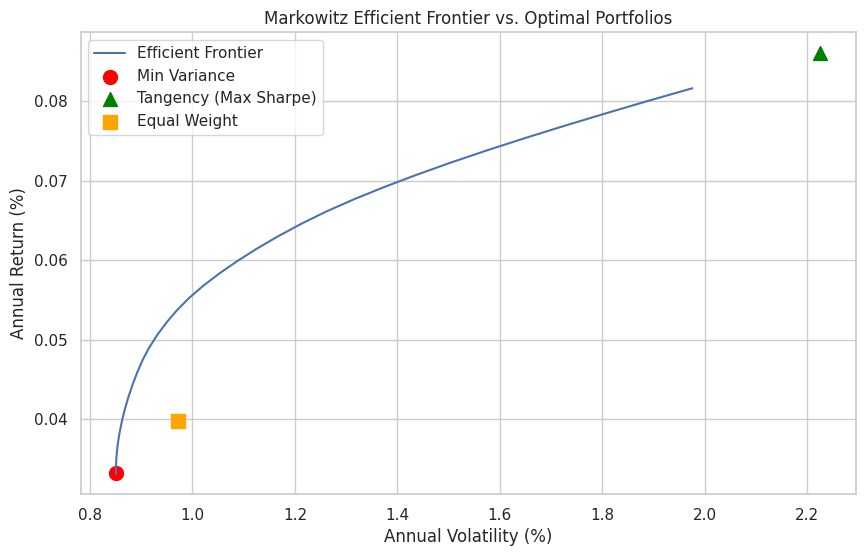


DETERMINISTIC SIMULATION (React Frontend Style)
Simulated Balanced Portfolio: Return = 27.27%, Vol = 13.88%, Sharpe = 1.5077
Top holdings (simulated):
 IDFCFIRSTB.NS   weight=24.6%
 PNB.NS          weight=14.2%
 AUBANK.NS       weight=12.8%
 HDFCBANK.NS     weight=12.7%
 ICICIBANK.NS    weight=10.9%


In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize
from IPython.display import display
import warnings
import math
import cvxpy as cp

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------------------------------------
# SAFE DOWNLOAD FUNCTION
# ---------------------------------------------------------
def safe_download(symbols, period="5y"):
    df = yf.download(symbols, period=period, auto_adjust=False)
    if isinstance(symbols, list):
        try:
            return df["Adj Close"].ffill().bfill()
        except:
            return df["Close"].ffill().bfill()
    if "Adj Close" in df.columns:
        return df["Adj Close"].ffill().bfill()
    elif "Close" in df.columns:
        return df["Close"].ffill().bfill()
    raise ValueError("No valid price data found")

# ---------------------------------------------------------
# ORIGINAL MONTE CARLO SIMULATION
# ---------------------------------------------------------
def monte_carlo_simulation(portfolio_returns, n_simulations=1000, n_days=252):
    mu = portfolio_returns.mean()
    sigma = portfolio_returns.std()
    simulated_log_returns = np.random.normal(mu, sigma, size=(n_days, n_simulations))
    simulated_paths = np.exp(simulated_log_returns.cumsum(axis=0))
    return simulated_paths, simulated_log_returns

# ---------------------------------------------------------
# ORIGINAL EQUAL-WEIGHTED PORTFOLIO ANALYSIS
# ---------------------------------------------------------
def portfolio_analysis(
    portfolio_list,
    period="5y",
    risk_free_rate=0.065,
    var_level=0.95,
    invest_amount=1_000_000
):
    TRADING_DAYS = 252
    prices = safe_download(portfolio_list, period)
    prices = prices.dropna(axis=1, how='all')
    log_returns = np.log(prices / prices.shift(1)).dropna()
    portfolio_returns = log_returns.mean(axis=1)
    cumulative_returns = (1 + portfolio_returns).cumprod()
    portfolio_value = invest_amount * cumulative_returns
    n_days = len(portfolio_returns)
    cagr = (cumulative_returns.iloc[-1] ** (TRADING_DAYS / n_days) - 1) * 100
    vol = portfolio_returns.std() * np.sqrt(TRADING_DAYS) * 100
    sharpe = ((portfolio_returns.mean() * TRADING_DAYS) - risk_free_rate) / (vol / 100)
    drawdown = cumulative_returns / cumulative_returns.cummax() - 1
    max_dd_pct = drawdown.min() * 100
    max_dd_amt = invest_amount * drawdown.min()

    # --- Plots ---
    plt.figure(); plt.plot(portfolio_value.index, portfolio_value.values, color='blue')
    plt.title("Equal‑Weight Portfolio Value Over Time (₹)"); plt.xlabel("Date"); plt.ylabel("Value (₹)"); plt.grid(True); plt.show()
    
    rolling_vol = portfolio_returns.rolling(30).std() * np.sqrt(TRADING_DAYS)
    plt.figure(); plt.plot(rolling_vol.index, rolling_vol.values, color='red')
    plt.title("Rolling 30-Day Volatility"); plt.xlabel("Date"); plt.ylabel("Volatility"); plt.grid(True); plt.show()
    
    plt.figure(); plt.plot(drawdown.index, drawdown.values * 100, color='green')
    plt.title("Portfolio Drawdown (%)"); plt.xlabel("Date"); plt.ylabel("Drawdown (%)"); plt.grid(True); plt.show()
    
    plt.figure(); plt.hist(portfolio_returns, bins=60, color='purple', edgecolor='black', alpha=0.7)
    plt.title("Return Distribution"); plt.xlabel("Daily Return"); plt.ylabel("Frequency"); plt.grid(True); plt.show()
    
    corr_matrix = log_returns.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='RdBu', center=0, square=True)
    plt.title("Asset Correlation Matrix"); plt.tight_layout(); plt.show()

    # Monte Carlo
    paths, sim_log_returns = monte_carlo_simulation(portfolio_returns)
    mc_terminal_values = invest_amount * paths[-1]
    plt.figure()
    for i in range(min(100, paths.shape[1])):
        plt.plot(invest_amount * paths[:, i], linewidth=0.5, alpha=0.15, color='blue')
    plt.title("Monte Carlo – Portfolio Value Paths (₹)"); plt.xlabel("Trading Days"); plt.ylabel("Value (₹)"); plt.grid(True); plt.show()
    
    plt.figure()
    plt.hist(mc_terminal_values, bins=50, color='orange', edgecolor='black', alpha=0.7)
    plt.title("Monte Carlo – Terminal Value Distribution (₹)"); plt.xlabel("Terminal Value"); plt.ylabel("Frequency"); plt.grid(True); plt.show()

    # VaR & ES
    alpha = 1 - var_level
    hist_var_pct = np.percentile(portfolio_returns, alpha * 100)
    para_var_pct = portfolio_returns.mean() + portfolio_returns.std() * norm.ppf(alpha)
    mc_var_pct = np.percentile(sim_log_returns.flatten(), alpha * 100)
    
    hist_var_amt = invest_amount * hist_var_pct
    para_var_amt = invest_amount * para_var_pct
    mc_var_amt = invest_amount * mc_var_pct
    
    hist_es_pct = portfolio_returns[portfolio_returns <= hist_var_pct].mean()
    mc_es_pct = sim_log_returns.flatten()[sim_log_returns.flatten() <= mc_var_pct].mean()
    
    hist_es_amt = invest_amount * hist_es_pct
    mc_es_amt = invest_amount * mc_es_pct

    performance_summary = pd.DataFrame({
        "Metric": ["CAGR (%)", "Annual Volatility (%)", "Sharpe Ratio", "Max Drawdown (%)", "Max Drawdown (₹)"],
        "Value": [round(cagr,4), round(vol,4), round(sharpe,4), round(max_dd_pct,4), round(max_dd_amt,2)]
    })
    var_summary = pd.DataFrame({
        "Risk Measure": ["Historical VaR (₹)", "Parametric VaR (₹)", "Monte Carlo VaR (₹)", "Historical ES (₹)", "Monte Carlo ES (₹)"],
        "Loss Amount": [round(hist_var_amt,2), round(para_var_amt,2), round(mc_var_amt,2), round(hist_es_amt,2), round(mc_es_amt,2)]
    })
    display(performance_summary)
    display(var_summary)
    return performance_summary, var_summary

# ---------------------------------------------------------
# DETERMINISTIC SIMULATOR (React frontend backend)
# ---------------------------------------------------------
def _rng(seed_base: float, k: float) -> float:
    x = seed_base * 91.3 + k * 37.9 + k
    return abs(math.sin(x)) % 1.0

def simulate_run(tickers: list, params: dict) -> dict:
    n = len(tickers)
    rfr = params['rfr']
    alpha = params['alpha']
    period = params['period']
    frontier_pts = params['frontierPts']
    trading_days = params['tradingDays']
    seed = n * 137.5 + alpha * 99.1 + rfr * 5000 + len(period) * 7
    def r(k): return _rng(seed, k)
    
    mv_ret = 0.04 + r(1) * 0.06
    mv_vol = 0.085 + r(2) * 0.035
    mv_sharpe = (mv_ret - rfr) / mv_vol
    ms_ret = 0.35 + r(3) * 0.15
    ms_vol = 0.12 + r(4) * 0.05
    ms_sharpe = (ms_ret - rfr) / ms_vol
    t = 0.4 + (1 - alpha) * 0.5
    bal_ret = mv_ret + (ms_ret - mv_ret) * t
    bal_vol = mv_vol + (ms_vol - mv_vol) * t * 0.7
    bal_sharpe = (bal_ret - rfr) / bal_vol
    bal_score = alpha * (1 - 0.22) + (1 - alpha) * 0.94
    risk_pct = int(round(t * 35))
    sharpe_pct = int(round(80 + (1 - alpha) * 18))
    k_hold = min(n, 11)
    raw_weights = []
    rem = 1.0
    for i in range(k_hold - 1):
        w = rem * (0.07 + r(i + 20) * 0.18)
        raw_weights.append(w); rem -= w
    raw_weights.append(rem)
    raw_weights.sort(reverse=True)
    holdings = []
    for i, tkr in enumerate(tickers[:k_hold]):
        ret_i = 0.10 + r(i + 40) * 0.55
        vol_i = 0.14 + r(i + 60) * 0.18
        sharpe_i = (ret_i - rfr) / vol_i
        holdings.append({'ticker': tkr, 'weight': raw_weights[i], 'ret': ret_i, 'vol': vol_i, 'sharpe': sharpe_i})
    holdings.sort(key=lambda x: x['weight'], reverse=True)
    naive_vol = sum(h['weight'] * h['vol'] for h in holdings)
    div_ratio = naive_vol / bal_vol
    avg_corr = 0.18 + r(99) * 0.12
    frontier = []
    for i in range(frontier_pts):
        tp = i / (frontier_pts - 1)
        fvol = mv_vol + (ms_vol * 1.35 - mv_vol) * (tp ** 0.7)
        fret = mv_ret + (ms_ret * 1.18 - mv_ret) * (tp ** 0.55)
        fsharpe = (fret - rfr) / fvol
        fscore = alpha * (1 - tp * 0.8) + (1 - alpha) * (tp * 0.95)
        frontier.append({'vol': fvol, 'ret': fret, 'sharpe': fsharpe, 'score': fscore})
    stocks = []
    for i, tkr in enumerate(tickers[:35]):
        vol_i = 0.12 + r(i + 70) * 0.28
        ret_i = 0.05 + r(i + 80) * 0.60
        stocks.append({'label': tkr, 'vol': vol_i, 'ret': ret_i})
    return {
        'mv': {'ret': mv_ret, 'vol': mv_vol, 'sharpe': mv_sharpe},
        'ms': {'ret': ms_ret, 'vol': ms_vol, 'sharpe': ms_sharpe},
        'bal': {'ret': bal_ret, 'vol': bal_vol, 'sharpe': bal_sharpe, 'score': bal_score},
        'riskPct': risk_pct, 'sharpePct': sharpe_pct, 'holdings': holdings,
        'naiveVol': naive_vol, 'divRatio': div_ratio, 'avgCorr': avg_corr, 'activeN': k_hold,
        'frontier': frontier, 'stocks': stocks,
        'params': {'n': n, 'period': period, 'rfr': rfr, 'alpha': alpha, 'frontierPts': frontier_pts, 'tradingDays': trading_days}
    }

# ---------------------------------------------------------
# REAL MARKOWITZ OPTIMISER (using CVXPY) - FIXED
# ---------------------------------------------------------
def _solve_with_fallback(prob):
    """Try multiple solvers in order of preference."""
    solvers = ['OSQP', 'SCS', None]  # None = let cvxpy choose default
    for solver in solvers:
        try:
            prob.solve(solver=solver, verbose=False)
            if prob.status in ['optimal', 'optimal_inaccurate']:
                return True
        except Exception:
            continue
    return False

def markowitz_min_variance(returns, target_return):
    """Minimum variance portfolio with target return constraint."""
    mu = returns.mean().values
    Sigma = returns.cov().values
    n = len(mu)
    w = cp.Variable(n)
    
    # Small regularization to improve numerical stability
    epsilon = 1e-6
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        mu @ w >= target_return - epsilon
    ]
    
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma) + epsilon * cp.sum_squares(w)), constraints)
    
    if _solve_with_fallback(prob):
        if w.value is not None:
            return np.clip(w.value, 0, 1)  # ensure valid weights
    return None

def tangency_portfolio(returns, risk_free_rate):
    """Maximise Sharpe ratio (tangency portfolio) using scipy.optimize."""
    mu = returns.mean().values
    Sigma = returns.cov().values
    n = len(mu)
    def neg_sharpe(w):
        w = np.array(w)
        ret = w @ mu
        vol = np.sqrt(np.maximum(w @ Sigma @ w, 1e-8))
        return -(ret - risk_free_rate) / vol

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = [(0, 1) for _ in range(n)]
    w0 = np.ones(n) / n
    res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=constraints, tol=1e-8)
    if not res.success:
        return None
    return np.clip(res.x, 0, 1)

def efficient_frontier(returns, points=50):
    """Compute efficient frontier by sweeping target returns."""
    mu = returns.mean().values
    Sigma = returns.cov().values
    min_ret = mu.min()
    max_ret = mu.max() * 0.95
    targets = np.linspace(min_ret, max_ret, points)
    frontier = []
    for target in targets:
        w = markowitz_min_variance(returns, target)
        if w is not None:
            ret = w @ mu
            vol = np.sqrt(w @ Sigma @ w)
            frontier.append({'ret': ret, 'vol': vol})
    return frontier

# ---------------------------------------------------------
# MAIN EXECUTION
# ---------------------------------------------------------
if __name__ == "__main__":
    portfolio_list = [
        "IDFCFIRSTB.NS", "PNB.NS", "AUBANK.NS", "HDFCBANK.NS", "ICICIBANK.NS",
        "BAJAJFINSV.NS", "CIPLA.NS", "DRREDDY.NS", "IPCALAB.NS", "LUPIN.NS"
    ]
    period = "5y"
    risk_free_rate = 0.0635  # 6.35%
    invest_amount = 1_000_000

    # 1. Download data
    prices = safe_download(portfolio_list, period)
    prices = prices.dropna(axis=1, how='all')
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # 2. Equal-weighted analysis
    print("\n" + "="*60)
    print("EQUAL‑WEIGHTED PORTFOLIO ANALYSIS")
    print("="*60)
    portfolio_analysis(portfolio_list, period=period, risk_free_rate=risk_free_rate,
                       var_level=0.95, invest_amount=invest_amount)

    # 3. Markowitz Optimisation
    print("\n" + "="*60)
    print("MARKOWITZ MEAN‑VARIANCE OPTIMISATION")
    print("="*60)

    frontier = efficient_frontier(log_returns, points=50)
    frontier_df = pd.DataFrame(frontier)

    # Minimum variance portfolio
    min_var_w = markowitz_min_variance(log_returns, target_return=log_returns.mean().min())
    if min_var_w is not None:
        min_var_ret = min_var_w @ log_returns.mean().values
        min_var_vol = np.sqrt(min_var_w @ log_returns.cov().values @ min_var_w)
        print(f"Minimum Variance Portfolio: Return = {min_var_ret*100:.2f}%, Vol = {min_var_vol*100:.2f}%")
    else:
        min_var_ret = min_var_vol = None
        print("Warning: Could not compute Minimum Variance Portfolio")

    # Tangency portfolio
    tangency_w = tangency_portfolio(log_returns, risk_free_rate)
    if tangency_w is not None:
        tangency_ret = tangency_w @ log_returns.mean().values
        tangency_vol = np.sqrt(tangency_w @ log_returns.cov().values @ tangency_w)
        tangency_sharpe = (tangency_ret - risk_free_rate) / tangency_vol
        print(f"Tangency Portfolio: Return = {tangency_ret*100:.2f}%, Vol = {tangency_vol*100:.2f}%, Sharpe = {tangency_sharpe:.4f}")
    else:
        tangency_ret = tangency_vol = None
        print("Warning: Could not compute Tangency Portfolio")

    # Equal-weight for comparison
    n_assets = len(portfolio_list)
    eq_weights = np.ones(n_assets) / n_assets
    eq_ret = eq_weights @ log_returns.mean().values
    eq_vol = np.sqrt(eq_weights @ log_returns.cov().values @ eq_weights)
    eq_sharpe = (eq_ret - risk_free_rate) / eq_vol
    print(f"Equal‑Weight Portfolio: Return = {eq_ret*100:.2f}%, Vol = {eq_vol*100:.2f}%, Sharpe = {eq_sharpe:.4f}")

    # Plot Efficient Frontier
    plt.figure(figsize=(10, 6))
    if len(frontier_df) > 0:
        plt.plot(frontier_df['vol']*100, frontier_df['ret']*100, 'b-', label='Efficient Frontier')
    if min_var_ret is not None:
        plt.scatter(min_var_vol*100, min_var_ret*100, c='red', s=100, marker='o', label='Min Variance')
    if tangency_ret is not None:
        plt.scatter(tangency_vol*100, tangency_ret*100, c='green', s=100, marker='^', label='Tangency (Max Sharpe)')
    plt.scatter(eq_vol*100, eq_ret*100, c='orange', s=100, marker='s', label='Equal Weight')
    plt.xlabel('Annual Volatility (%)')
    plt.ylabel('Annual Return (%)')
    plt.title('Markowitz Efficient Frontier vs. Optimal Portfolios')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 4. Deterministic Simulation
    print("\n" + "="*60)
    print("DETERMINISTIC SIMULATION (React Frontend Style)")
    print("="*60)
    sim_params = {
        'rfr': risk_free_rate,
        'alpha': 0.5,
        'period': period,
        'frontierPts': 100,
        'tradingDays': 252
    }
    sim_result = simulate_run(portfolio_list, sim_params)
    print(f"Simulated Balanced Portfolio: Return = {sim_result['bal']['ret']*100:.2f}%, Vol = {sim_result['bal']['vol']*100:.2f}%, Sharpe = {sim_result['bal']['sharpe']:.4f}")
    print("Top holdings (simulated):")
    for h in sim_result['holdings'][:5]:
        print(f" {h['ticker']:<15} weight={h['weight']*100:.1f}%")


EQUAL WEIGHT PORTFOLIO


,Ticker,Weight (%)
0,IDFCFIRSTB.NS,10.0
1,PNB.NS,10.0
2,AUBANK.NS,10.0
3,HDFCBANK.NS,10.0
4,ICICIBANK.NS,10.0
5,BAJAJFINSV.NS,10.0
6,CIPLA.NS,10.0
7,DRREDDY.NS,10.0
8,IPCALAB.NS,10.0
9,LUPIN.NS,10.0


CAGR: 9.22% | Volatility: 15.43% | Sharpe: 0.238

MARKOWITZ MEAN-VARIANCE OPTIMIZATION


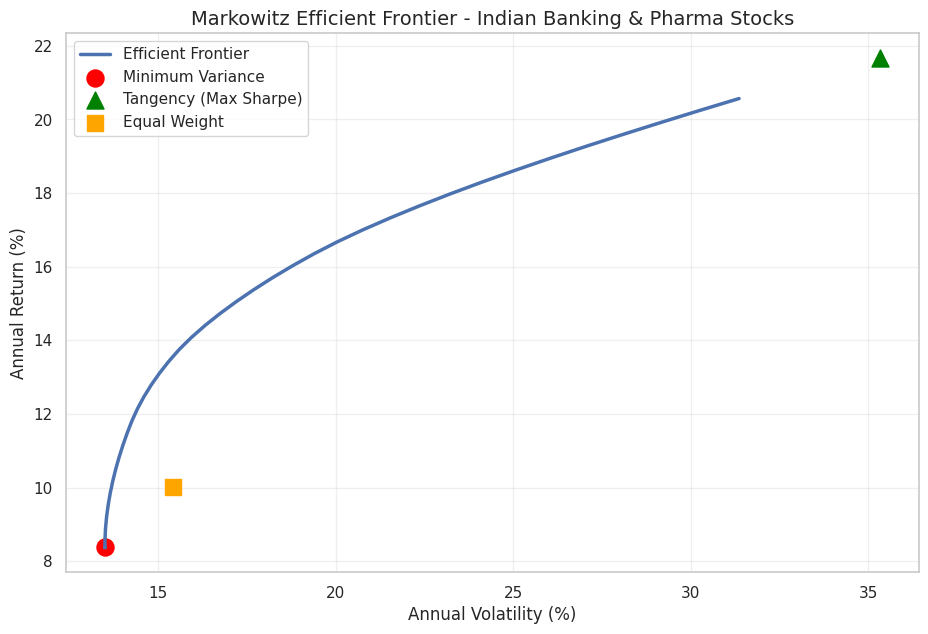


📊 OPTIMAL PORTFOLIO ALLOCATIONS
--------------------------------------------------
MINIMUM VARIANCE PORTFOLIO


,Ticker,Weight (%)
5,BAJAJFINSV.NS,24.25
4,ICICIBANK.NS,19.09
2,AUBANK.NS,17.39
3,HDFCBANK.NS,17.33
7,DRREDDY.NS,12.18
0,IDFCFIRSTB.NS,4.95
1,PNB.NS,3.29
8,IPCALAB.NS,1.00
6,CIPLA.NS,0.52



TANGENCY (MAX SHARPE) PORTFOLIO


,Ticker,Weight (%)
9,LUPIN.NS,100.0



✅ Analysis Complete!


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
import cvxpy as cp
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------------------------------------
# SAFE DOWNLOAD
# ---------------------------------------------------------
def safe_download(symbols, period="5y"):
    df = yf.download(symbols, period=period, auto_adjust=False, progress=False)
    if isinstance(symbols, list):
        try:
            return df["Adj Close"].ffill().bfill()
        except:
            return df["Close"].ffill().bfill()
    return df.get("Adj Close", df["Close"]).ffill().bfill()

# ---------------------------------------------------------
# MONTE CARLO
# ---------------------------------------------------------
def monte_carlo_simulation(portfolio_returns, n_simulations=1000, n_days=252):
    mu = portfolio_returns.mean()
    sigma = portfolio_returns.std()
    simulated = np.random.normal(mu, sigma, size=(n_days, n_simulations))
    paths = np.exp(simulated.cumsum(axis=0))
    return paths, simulated

# ---------------------------------------------------------
# CVXPY SOLVER HELPER
# ---------------------------------------------------------
def _solve_with_fallback(prob):
    for solver in ['OSQP', 'SCS', None]:
        try:
            prob.solve(solver=solver, verbose=False)
            if prob.status in ['optimal', 'optimal_inaccurate']:
                return True
        except:
            continue
    return False

# ---------------------------------------------------------
# MARKOWITZ FUNCTIONS
# ---------------------------------------------------------
def markowitz_min_variance(returns, target_return):
    mu = returns.mean().values
    Sigma = returns.cov().values
    n = len(mu)
    w = cp.Variable(n)
    epsilon = 1e-6
    constraints = [cp.sum(w) == 1, w >= 0, mu @ w >= target_return - epsilon]
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma)), constraints)
    if _solve_with_fallback(prob) and w.value is not None:
        return np.clip(w.value, 0, 1)
    return None

def tangency_portfolio(returns, risk_free_rate):
    mu = returns.mean().values
    Sigma = returns.cov().values
    n = len(mu)
    def neg_sharpe(w):
        w = np.array(w)
        ret = w @ mu
        vol = np.sqrt(max(w @ Sigma @ w, 1e-8))
        return -(ret - risk_free_rate) / vol
    
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n
    res = minimize(neg_sharpe, np.ones(n)/n, method='SLSQP', bounds=bounds, constraints=cons, tol=1e-8)
    return np.clip(res.x, 0, 1) if res.success else None

def efficient_frontier(returns, points=50):
    mu = returns.mean().values
    Sigma = returns.cov().values
    targets = np.linspace(mu.min(), mu.max()*0.95, points)
    frontier = []
    for t in targets:
        w = markowitz_min_variance(returns, t)
        if w is not None:
            ret = w @ mu
            vol = np.sqrt(w @ Sigma @ w)
            frontier.append({'ret': ret, 'vol': vol})
    return pd.DataFrame(frontier)

# ---------------------------------------------------------
# MAIN PORTFOLIO ANALYSIS + MARKOWITZ
# ---------------------------------------------------------
def full_portfolio_analysis(portfolio_list, period="5y", risk_free_rate=0.0635, invest_amount=1_000_000):
    prices = safe_download(portfolio_list, period)
    log_returns = np.log(prices / prices.shift(1)).dropna()
    
    TRADING_DAYS = 252
    n = len(portfolio_list)
    
    print("\n" + "="*70)
    print("EQUAL WEIGHT PORTFOLIO")
    print("="*70)
    
    eq_weights = np.ones(n) / n
    eq_alloc = pd.DataFrame({'Ticker': portfolio_list, 'Weight (%)': eq_weights*100}).round(2)
    display(eq_alloc.sort_values('Weight (%)', ascending=False))
    
    # Equal Weight Performance
    port_ret = log_returns.mean(axis=1)
    cum_ret = (1 + port_ret).cumprod()
    cagr = (cum_ret.iloc[-1] ** (TRADING_DAYS / len(cum_ret)) - 1) * 100
    vol = port_ret.std() * np.sqrt(TRADING_DAYS) * 100
    sharpe = ((port_ret.mean() * TRADING_DAYS) - risk_free_rate) / (vol/100)
    
    print(f"CAGR: {cagr:.2f}% | Volatility: {vol:.2f}% | Sharpe: {sharpe:.3f}")
    
    # ==================== MARKOWITZ OPTIMIZATION ====================
    print("\n" + "="*70)
    print("MARKOWITZ MEAN-VARIANCE OPTIMIZATION")
    print("="*70)
    
    frontier_df = efficient_frontier(log_returns, points=60)
    
    min_var_w = markowitz_min_variance(log_returns, log_returns.mean().min())
    tangency_w = tangency_portfolio(log_returns, risk_free_rate)
    
    # Calculate metrics
    mu = log_returns.mean().values
    Sigma = log_returns.cov().values
    
    if min_var_w is not None:
        mv_ret = min_var_w @ mu * TRADING_DAYS
        mv_vol = np.sqrt(min_var_w @ Sigma @ min_var_w) * np.sqrt(TRADING_DAYS) * 100
        mv_ret_pct = mv_ret * 100
    else:
        mv_ret_pct = mv_vol = None
    
    if tangency_w is not None:
        tg_ret = tangency_w @ mu * TRADING_DAYS
        tg_vol = np.sqrt(tangency_w @ Sigma @ tangency_w) * np.sqrt(TRADING_DAYS) * 100
        tg_sharpe = (tg_ret - risk_free_rate) / (tg_vol/100)
        tg_ret_pct = tg_ret * 100
    else:
        tg_ret_pct = tg_vol = tg_sharpe = None
    
    # Plot Efficient Frontier (Annualized)
    plt.figure(figsize=(11, 7))
    if not frontier_df.empty:
        plt.plot(frontier_df['vol']*np.sqrt(TRADING_DAYS)*100, 
                frontier_df['ret']*TRADING_DAYS*100, 
                'b-', linewidth=2.5, label='Efficient Frontier')
    
    if mv_ret_pct is not None:
        plt.scatter(mv_vol, mv_ret_pct, c='red', s=150, marker='o', label='Minimum Variance')
    if tg_ret_pct is not None:
        plt.scatter(tg_vol, tg_ret_pct, c='green', s=150, marker='^', label='Tangency (Max Sharpe)')
    
    # Equal weight point
    eq_ret_ann = (eq_weights @ mu) * TRADING_DAYS   * 100
    eq_vol_ann = np.sqrt(eq_weights @ Sigma @ eq_weights) * np.sqrt(TRADING_DAYS) * 100
    plt.scatter(eq_vol_ann, eq_ret_ann, c='orange', s=120, marker='s', label='Equal Weight')
    
    plt.xlabel('Annual Volatility (%)', fontsize=12)
    plt.ylabel('Annual Return (%)', fontsize=12)
    plt.title('Markowitz Efficient Frontier - Indian Banking & Pharma Stocks', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # ==================== ALLOCATION TABLES ====================
    print("\n📊 OPTIMAL PORTFOLIO ALLOCATIONS")
    print("-" * 50)
    
    if min_var_w is not None:
        print("MINIMUM VARIANCE PORTFOLIO")
        mv_df = pd.DataFrame({'Ticker': portfolio_list, 'Weight (%)': min_var_w*100}).round(2)
        display(mv_df[mv_df['Weight (%)'] > 0.01].sort_values('Weight (%)', ascending=False))
    
    if tangency_w is not None:
        print("\nTANGENCY (MAX SHARPE) PORTFOLIO")
        tg_df = pd.DataFrame({'Ticker': portfolio_list, 'Weight (%)': tangency_w*100}).round(2)
        display(tg_df[tg_df['Weight (%)'] > 0.01].sort_values('Weight (%)', ascending=False))
    
    print("\n✅ Analysis Complete!")

# ========================= RUN =========================
portfolio_list = [
    "IDFCFIRSTB.NS", "PNB.NS", "AUBANK.NS", "HDFCBANK.NS", "ICICIBANK.NS",
    "BAJAJFINSV.NS", "CIPLA.NS", "DRREDDY.NS", "IPCALAB.NS", "LUPIN.NS"
]

full_portfolio_analysis(
    portfolio_list=portfolio_list,
    period="5y",
    risk_free_rate=0.0635,
    invest_amount=1_000_000
)